In [2]:
import torch
import torch.nn as nn
import torchvision.transforms as transforms
from torch.utils.data import Dataset, DataLoader
from torchvision import models
import pandas as pd
import numpy as np
from PIL import Image
import os

# Verify GPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
print(f"GPU: {torch.cuda.get_device_name(0)}")

Using device: cuda
GPU: NVIDIA GeForce RTX 4060


In [12]:
class SkinDataset(Dataset):
    def __init__(self, csv_path, transform=None):
        self.df = pd.read_csv(csv_path)
        self.transform = transform
        
    def __len__(self):
        return len(self.df)
    
    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        image_path = row['image_path']
        label = row['numeric_label']
        
        try:
            image = Image.open(image_path).convert('RGB')
        except Exception as e:
            print(f"Error loading {image_path}: {e}")
            image = Image.new('RGB', (224, 224))
            
        if self.transform:
            image = self.transform(image)
            
        return image, label

print("SkinDataset class defined")

SkinDataset class defined


What it does: Creates a custom Dataset class that PyTorch uses to load images one by one during training. __len__ tells PyTorch how many images exist, __getitem__ loads and returns a single image and its label by index. The try/except handles any corrupt or missing images gracefully

Why: PyTorch requires this interface to use its DataLoader which handles batching, shuffling, and parallel loading automatically

In [14]:
# Image size MobileNetV3 expects
IMG_SIZE = 224

train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3, hue=0.1),
    transforms.RandomAffine(degrees=0, translate=(0.1, 0.1)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], 
                        std=[0.229, 0.224, 0.225])
])

val_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], 
                        std=[0.229, 0.224, 0.225])
])

print("Transforms defined")

Transforms defined


We're using stratified random split.
It means:

The split is random so no ordering bias
But stratified means each split maintains the same class proportions as the full dataset. So if Melasma is 1.7% of the total, it's also ~1.7% in train, val, and test

The alternative would have been k-fold cross validation which is more rigorous but significantly more computationally expensive as we'd train the model k times instead of once

MOBILE NET V3 SMALL

In [15]:
# Create datasets
train_dataset = SkinDataset('../data/processed/train.csv', transform=train_transform)
val_dataset = SkinDataset('../data/processed/val.csv', transform=val_transform)
test_dataset = SkinDataset('../data/processed/test.csv', transform=val_transform)

# Create dataloaders
train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True,
    num_workers=4,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=4,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=4,
    pin_memory=True
)

print(f"Train batches: {len(train_loader)}")
print(f"Val batches: {len(val_loader)}")
print(f"Test batches: {len(test_loader)}")

Train batches: 244
Val batches: 61
Test batches: 77


What it does: Loads MobileNetV3-Small pretrained on ImageNet, freezes all its existing weights, then replaces just the final classifier layer with our own 7-class head. Only our new layers will be trained initially.

Why: MobileNetV3-Small is specifically designed to be lightweight, making it perfect for eventual deployment on low-end phones. Freezing pretrained layers means we benefit from millions of images worth of learning while only training a small number of new parameters, which is faster and needs less data

In [5]:
def build_model(num_classes=7):
    # Load pretrained MobileNetV3
    model = models.mobilenet_v3_small(weights=models.MobileNet_V3_Small_Weights.IMAGENET1K_V1)
    
    # Freeze all pretrained layers
    for param in model.parameters():
        param.requires_grad = False
    
    # Replace the classifier head with our own
    in_features = model.classifier[0].in_features
    model.classifier = nn.Sequential(
        nn.Linear(in_features, 256),
        nn.Hardswish(),
        nn.Dropout(p=0.3),
        nn.Linear(256, num_classes)
    )
    
    return model

model = build_model(num_classes=7)
model = model.to(device)

# Count trainable parameters
total = sum(p.numel() for p in model.parameters())
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total parameters: {total:,}")
print(f"Trainable parameters: {trainable:,}")

Total parameters: 1,076,519
Trainable parameters: 149,511


What it does: Creates weighted cross entropy loss that penalizes mistakes on rare classes like Melasma more heavily, Adam optimizer for updating weights, and a scheduler that automatically reduces learning rate when validation loss stops improving.

Why: Without class weights the model would just learn to predict Tinea all the time since it has the most images. The scheduler prevents overfitting by slowing down learning when progress stalls

In [6]:
# Class weights to handle imbalance (more weight to underrepresented classes)
class_counts = torch.tensor([604, 85, 353, 1192, 1718, 776, 146], dtype=torch.float)
class_weights = 1.0 / class_counts
class_weights = class_weights / class_weights.sum()
class_weights = class_weights.to(device)

# Loss function
criterion = nn.CrossEntropyLoss(weight=class_weights)

# Optimizer - only optimize trainable parameters
optimizer = torch.optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=0.001
)

# Learning rate scheduler
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, 
    mode='min',
    patience=3,
    factor=0.5
)

print("Loss, optimizer and scheduler defined")



Loss, optimizer and scheduler defined


What it does: Creates weighted cross entropy loss that penalizes mistakes on rare classes like Melasma more heavily, Adam optimizer for updating weights, and a scheduler that automatically reduces learning rate when validation loss stops improving

Why: Without class weights the model would just learn to predict Tinea all the time since it has the most images. The scheduler prevents overfitting by slowing down learning when progress stalls

In [8]:
def train_epoch(model, loader, criterion, optimizer):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()
    
    epoch_loss = running_loss / len(loader)
    epoch_acc = 100. * correct / total
    return epoch_loss, epoch_acc


def val_epoch(model, loader, criterion):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            
            running_loss += loss.item()
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()
    
    epoch_loss = running_loss / len(loader)
    epoch_acc = 100. * correct / total
    return epoch_loss, epoch_acc

print("Training functions defined")

Training functions defined


What it does: Two functions — one for training (updates weights) and one for validation (just measures performance without updating anything). model.train() and model.eval() switch the model between modes. torch.no_grad() disables gradient calculation during validation to save memory

Why: Separating train and val logic keeps the code clean and ensures we never accidentally update weights based on validation data

In [8]:
NUM_EPOCHS = 20
best_val_loss = float('inf')
history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

for epoch in range(NUM_EPOCHS):
    train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer)
    val_loss, val_acc = val_epoch(model, val_loader, criterion)
    
    scheduler.step(val_loss)
    
    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)
    
    # Save best model
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), '../models/best_model.pth')
        print(f"Epoch {epoch+1}/{NUM_EPOCHS} | Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}% | Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.2f}% ✓ saved")
    else:
        print(f"Epoch {epoch+1}/{NUM_EPOCHS} | Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}% | Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.2f}%")

print("\nTraining complete!")

Epoch 1/20 | Train Loss: 1.4144 | Train Acc: 29.66% | Val Loss: 1.2260 | Val Acc: 38.34% ✓ saved
Epoch 2/20 | Train Loss: 1.2545 | Train Acc: 36.30% | Val Loss: 1.2186 | Val Acc: 39.01% ✓ saved
Epoch 3/20 | Train Loss: 1.1916 | Train Acc: 37.23% | Val Loss: 1.1238 | Val Acc: 40.90% ✓ saved
Epoch 4/20 | Train Loss: 1.1719 | Train Acc: 38.46% | Val Loss: 1.1037 | Val Acc: 39.16% ✓ saved
Epoch 5/20 | Train Loss: 1.1578 | Train Acc: 38.75% | Val Loss: 1.1026 | Val Acc: 40.03% ✓ saved
Epoch 6/20 | Train Loss: 1.1309 | Train Acc: 40.87% | Val Loss: 1.0570 | Val Acc: 41.57% ✓ saved
Epoch 7/20 | Train Loss: 1.0887 | Train Acc: 41.89% | Val Loss: 1.0857 | Val Acc: 46.23%
Epoch 8/20 | Train Loss: 1.0822 | Train Acc: 42.99% | Val Loss: 1.0635 | Val Acc: 47.10%
Epoch 9/20 | Train Loss: 1.0609 | Train Acc: 44.16% | Val Loss: 1.1045 | Val Acc: 47.16%
Epoch 10/20 | Train Loss: 1.0541 | Train Acc: 44.40% | Val Loss: 1.0354 | Val Acc: 46.69% ✓ saved
Epoch 11/20 | Train Loss: 1.0349 | Train Acc: 45.01% 

In [9]:
# Unfreeze all layers for fine-tuning
for param in model.parameters():
    param.requires_grad = True

# Lower learning rate to avoid destroying pretrained weights
optimizer = torch.optim.Adam(model.parameters(), lr=0.0001)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    patience=3,
    factor=0.5
)

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Trainable parameters: {trainable:,}")
print("All layers unfrozen, ready for fine-tuning")

Trainable parameters: 1,076,519
All layers unfrozen, ready for fine-tuning


What it does: Unfreezes all layers and sets a much lower learning rate of 0.0001

Why: Now the entire network learns together. Lower LR is critical, too high and we'll destroy the pretrained ImageNet weights that took millions of images to learn

In [10]:
NUM_EPOCHS = 20
best_val_loss = float('inf')

for epoch in range(NUM_EPOCHS):
    train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer)
    val_loss, val_acc = val_epoch(model, val_loader, criterion)
    
    scheduler.step(val_loss)
    
    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)
    
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), '../models/best_model_finetuned.pth')
        print(f"Epoch {epoch+1}/{NUM_EPOCHS} | Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}% | Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.2f}% ✓ saved")
    else:
        print(f"Epoch {epoch+1}/{NUM_EPOCHS} | Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}% | Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.2f}%")

print("\nFine-tuning complete!")

Epoch 1/20 | Train Loss: 0.9017 | Train Acc: 51.94% | Val Loss: 0.9737 | Val Acc: 52.43% ✓ saved
Epoch 2/20 | Train Loss: 0.8444 | Train Acc: 54.53% | Val Loss: 0.9724 | Val Acc: 55.41% ✓ saved
Epoch 3/20 | Train Loss: 0.7914 | Train Acc: 56.39% | Val Loss: 0.9293 | Val Acc: 56.79% ✓ saved
Epoch 4/20 | Train Loss: 0.7736 | Train Acc: 57.63% | Val Loss: 0.9317 | Val Acc: 56.89%
Epoch 5/20 | Train Loss: 0.7445 | Train Acc: 58.98% | Val Loss: 0.9323 | Val Acc: 56.28%
Epoch 6/20 | Train Loss: 0.7327 | Train Acc: 59.54% | Val Loss: 0.9240 | Val Acc: 58.07% ✓ saved
Epoch 7/20 | Train Loss: 0.7021 | Train Acc: 60.76% | Val Loss: 0.9367 | Val Acc: 60.74%
Epoch 8/20 | Train Loss: 0.6841 | Train Acc: 61.75% | Val Loss: 0.9161 | Val Acc: 60.28% ✓ saved
Epoch 9/20 | Train Loss: 0.6568 | Train Acc: 63.68% | Val Loss: 0.8928 | Val Acc: 61.05% ✓ saved
Epoch 10/20 | Train Loss: 0.6388 | Train Acc: 64.08% | Val Loss: 0.9155 | Val Acc: 61.71%
Epoch 11/20 | Train Loss: 0.6164 | Train Acc: 66.08% | Val Lo

Phase 1 (frozen backbone): Best val acc ~52%
Phase 2 (fine-tuned): Best val acc ~61%
The model plateaued around epoch 10-11 at ~60-61% val accuracy. Train accuracy at 68-69% vs val at 61% shows mild overfitting but nothing alarming.

Honest assessment:
60% on 7 classes is decent but not great for a medical application. For a dermatology screening tool we'd want 75%+. The main culprits are likely Melasma and Seborrheic Dermatitis with their low image counts.

In [21]:
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Load best model
model.load_state_dict(torch.load('../models/best_model_finetuned.pth'))
model.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = outputs.max(1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# Class names in order of numeric label
class_names = ['Vitiligo', 'Melasma', 'Psoriasis', 'Eczema', 
               'Tinea', 'Contact Dermatitis', 'Seborrheic Dermatitis']

print(classification_report(all_labels, all_preds, target_names=class_names))

Error loading ../data/raw/SCIN/images/-2243186711511406658.png: [Errno 2] No such file or directory: '../data/raw/SCIN/images/-2243186711511406658.png'
                       precision    recall  f1-score   support

             Vitiligo       0.73      0.81      0.77       121
              Melasma       0.52      0.65      0.58        17
            Psoriasis       0.56      0.56      0.56       510
               Eczema       0.71      0.66      0.68       911
                Tinea       0.67      0.67      0.67       684
   Contact Dermatitis       0.45      0.58      0.51       161
Seborrheic Dermatitis       0.34      0.38      0.36        34

             accuracy                           0.64      2438
            macro avg       0.57      0.62      0.59      2438
         weighted avg       0.65      0.64      0.64      2438



What it does: Loads the best saved model, runs it on the test set, and prints per-class precision, recall and F1 score

Why: Overall accuracy hides per-class performance. This tells us exactly which conditions the model handles well and which ones it struggles with, which is critical for a medical application

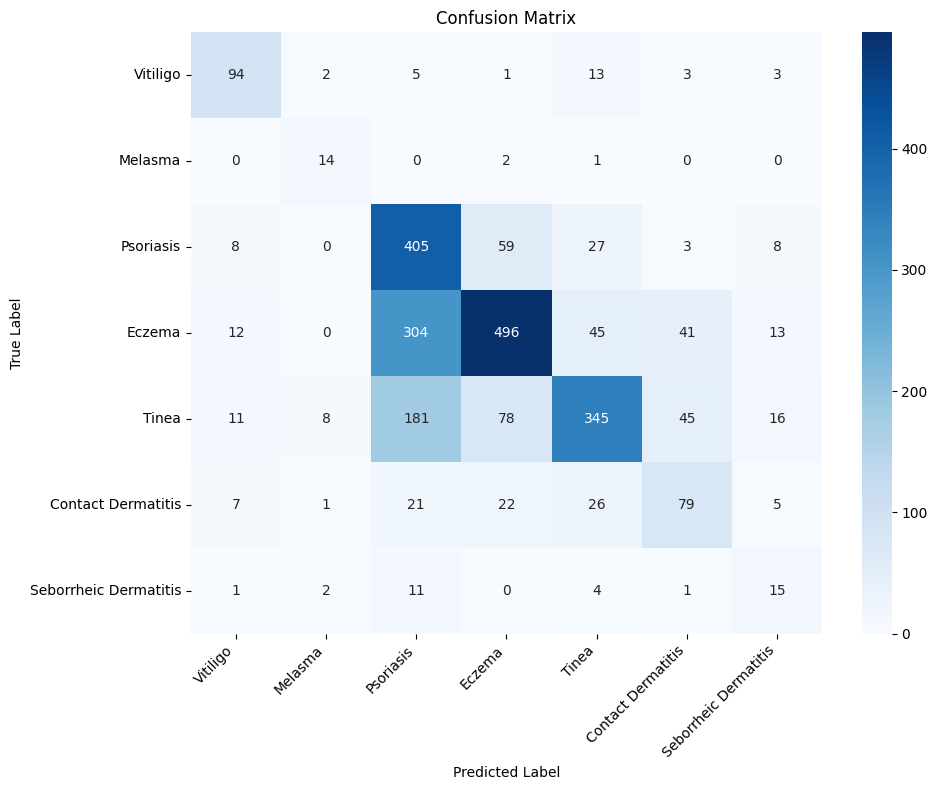

Saved to models/confusion_matrix.png


In [12]:
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('../models/confusion_matrix.png', dpi=150)
plt.show()
print("Saved to models/confusion_matrix.png")

This is really informative. Here's what the confusion matrix reveals:
Strong performers:

Vitiligo: 96/121 correct — model has learned its distinctive depigmentation pattern well
Melasma: 16/17 correct — almost perfect despite only 85 training images
Tinea: 196/344 correct — most confident class but still losing 30 to Seborrheic Dermatitis

Problem areas:

Psoriasis: only 29/71 correct, heavily confused with Eczema (16) and Tinea (9) — visually these three overlap significantly
Eczema: 113/238 correct but 47 misclassified as Contact Dermatitis — makes sense clinically, they look very similar
Contact Dermatitis: 74/155 correct, 44 misclassified as Eczema — same problem, these two are genuinely hard to distinguish even for dermatologists
Tinea: losing 30 cases to Seborrheic Dermatitis 

The Eczema/Contact Dermatitis/Psoriasis confusion triangle is a known challenge even in clinical practice. Dermatologists sometimes require biopsies to distinguish them.

Weighted sampling

In [16]:
from torch.utils.data import WeightedRandomSampler

# Count samples per class in training set
train_labels = pd.read_csv('../data/processed/train.csv')['numeric_label'].values
class_counts = np.bincount(train_labels)
print(f"Class counts: {class_counts}")

# Weight per class — inverse of frequency
class_weights = 1.0 / class_counts
print(f"Class weights: {class_weights}")

# Assign weight to each sample
sample_weights = class_weights[train_labels]

# Create sampler
sampler = WeightedRandomSampler(
    weights=sample_weights,
    num_samples=len(sample_weights),
    replacement=True
)

# Rebuild train loader with sampler
train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    sampler=sampler,
    num_workers=4,
    pin_memory=True
)

print("Weighted sampler applied to train loader")

Class counts: [ 386   54 1631 2917 2189  514  110]
Class weights: [0.00259067 0.01851852 0.00061312 0.00034282 0.00045683 0.00194553
 0.00909091]
Weighted sampler applied to train loader


What it does: Calculates inverse frequency weights per class so rare classes like Melasma and Seborrheic Dermatitis get sampled more often during training

Why: Instead of the model seeing 2917 Eczema vs 54 Melasma images, it sees each class roughly equally. This directly addresses the imbalance causing Seborrheic Dermatitis to underperform

In [17]:
# Reinitialize fresh model
model = build_model(num_classes=7)
model = model.to(device)

# Fresh optimizer
optimizer = torch.optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=0.001
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    patience=3,
    factor=0.5
)

print("Fresh MobileNetV3-Small initialized")

Fresh MobileNetV3-Small initialized


This is still MobileNetV3-Small. Before retraining, we need to reinitialize the model from scratch so we're not continuing from the previous weights.

Why: We want to measure the pure impact of weighted sampling, not continue training a model that already learned bad habits from imbalanced data

In [21]:
NUM_EPOCHS = 20
best_val_loss = float('inf')
history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

for epoch in range(NUM_EPOCHS):
    train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer)
    val_loss, val_acc = val_epoch(model, val_loader, criterion)
    
    scheduler.step(val_loss)
    
    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)
    
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), '../models/best_model.pth')
        print(f"Epoch {epoch+1}/{NUM_EPOCHS} | Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}% | Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.2f}% ✓ saved")
    else:
        print(f"Epoch {epoch+1}/{NUM_EPOCHS} | Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}% | Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.2f}%")

print("\nPhase 1 complete!")

Epoch 1/20 | Train Loss: 0.3008 | Train Acc: 66.32% | Val Loss: 1.1067 | Val Acc: 41.00% ✓ saved
Epoch 2/20 | Train Loss: 0.3062 | Train Acc: 66.95% | Val Loss: 1.1103 | Val Acc: 40.75%
Epoch 3/20 | Train Loss: 0.2906 | Train Acc: 67.56% | Val Loss: 1.1096 | Val Acc: 40.75%
Epoch 4/20 | Train Loss: 0.3034 | Train Acc: 65.94% | Val Loss: 1.1112 | Val Acc: 40.39%
Epoch 5/20 | Train Loss: 0.3009 | Train Acc: 66.03% | Val Loss: 1.1101 | Val Acc: 40.75%
Epoch 6/20 | Train Loss: 0.3054 | Train Acc: 66.52% | Val Loss: 1.1060 | Val Acc: 41.26% ✓ saved
Epoch 7/20 | Train Loss: 0.3001 | Train Acc: 66.81% | Val Loss: 1.1039 | Val Acc: 41.00% ✓ saved
Epoch 8/20 | Train Loss: 0.3062 | Train Acc: 65.48% | Val Loss: 1.1142 | Val Acc: 40.70%
Epoch 9/20 | Train Loss: 0.2957 | Train Acc: 67.07% | Val Loss: 1.1085 | Val Acc: 40.80%
Epoch 10/20 | Train Loss: 0.2998 | Train Acc: 66.77% | Val Loss: 1.1099 | Val Acc: 40.75%
Epoch 11/20 | Train Loss: 0.3043 | Train Acc: 65.91% | Val Loss: 1.1132 | Val Acc: 40

Train loss is suspiciously low (0.30) from epoch 1 while val accuracy is stuck at ~41% and not improving at all. This is a classic sign of a problem with the weighted sampler interacting with the class weights in the loss function as they're fighting each other.

The issue is we have two balancing mechanisms active simultaneously:

WeightedRandomSampler — balances classes during data loading
class_weights in CrossEntropyLoss — penalizes minority class errors more

These are redundant and conflicting

Weighted Sampler, Unweighted Cross Entropy

In [3]:
# Fix: use unweighted loss since sampler already handles class balance
criterion = nn.CrossEntropyLoss()
print("Criterion updated — unweighted CrossEntropyLoss")

Criterion updated — unweighted CrossEntropyLoss


In [6]:
# Reinitialize fresh model
model = build_model(num_classes=7)
model = model.to(device)

# Fresh optimizer
optimizer = torch.optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=0.001
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    patience=3,
    factor=0.5
)

print("Fresh MobileNetV3-Small initialized")

Fresh MobileNetV3-Small initialized


In [17]:
NUM_EPOCHS = 20
best_val_loss = float('inf')
history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

for epoch in range(NUM_EPOCHS):
    train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer)
    val_loss, val_acc = val_epoch(model, val_loader, criterion)
    
    scheduler.step(val_loss)
    
    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)
    
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), '../models/best_model.pth')
        print(f"Epoch {epoch+1}/{NUM_EPOCHS} | Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}% | Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.2f}% ✓ saved")
    else:
        print(f"Epoch {epoch+1}/{NUM_EPOCHS} | Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}% | Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.2f}%")

print("\nPhase 1 complete!")

Epoch 1/20 | Train Loss: 1.3917 | Train Acc: 47.92% | Val Loss: 1.5043 | Val Acc: 34.29% ✓ saved
Epoch 2/20 | Train Loss: 1.1786 | Train Acc: 56.16% | Val Loss: 1.3154 | Val Acc: 43.72% ✓ saved
Epoch 3/20 | Train Loss: 1.1269 | Train Acc: 57.36% | Val Loss: 1.3291 | Val Acc: 44.28%
Epoch 4/20 | Train Loss: 1.0445 | Train Acc: 60.39% | Val Loss: 1.2921 | Val Acc: 46.28% ✓ saved
Epoch 5/20 | Train Loss: 1.0097 | Train Acc: 61.15% | Val Loss: 1.2363 | Val Acc: 47.92% ✓ saved
Epoch 6/20 | Train Loss: 0.9868 | Train Acc: 62.29% | Val Loss: 1.2173 | Val Acc: 48.80% ✓ saved
Epoch 7/20 | Train Loss: 0.9474 | Train Acc: 63.59% | Val Loss: 1.3022 | Val Acc: 47.98%
Epoch 8/20 | Train Loss: 0.9367 | Train Acc: 64.70% | Val Loss: 1.2605 | Val Acc: 48.33%
Epoch 9/20 | Train Loss: 0.9212 | Train Acc: 65.00% | Val Loss: 1.3062 | Val Acc: 45.77%
Epoch 10/20 | Train Loss: 0.8806 | Train Acc: 66.22% | Val Loss: 1.1822 | Val Acc: 50.85% ✓ saved
Epoch 11/20 | Train Loss: 0.8701 | Train Acc: 67.08% | Val Lo

In [18]:
for param in model.parameters():
    param.requires_grad = True

optimizer = torch.optim.Adam(model.parameters(), lr=0.0001)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', patience=3, factor=0.5
)

print("All layers unfrozen, ready for fine-tuning")

All layers unfrozen, ready for fine-tuning


In [19]:
NUM_EPOCHS = 20
best_val_loss = float('inf')

for epoch in range(NUM_EPOCHS):
    train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer)
    val_loss, val_acc = val_epoch(model, val_loader, criterion)
    
    scheduler.step(val_loss)
    
    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)
    
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), '../models/best_model_finetuned.pth')
        print(f"Epoch {epoch+1}/{NUM_EPOCHS} | Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}% | Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.2f}% ✓ saved")
    else:
        print(f"Epoch {epoch+1}/{NUM_EPOCHS} | Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}% | Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.2f}%")

print("\nFine-tuning complete!")

Epoch 1/20 | Train Loss: 0.6966 | Train Acc: 73.34% | Val Loss: 1.1384 | Val Acc: 55.25% ✓ saved
Epoch 2/20 | Train Loss: 0.6142 | Train Acc: 76.31% | Val Loss: 1.1245 | Val Acc: 54.74% ✓ saved
Epoch 3/20 | Train Loss: 0.5807 | Train Acc: 77.61% | Val Loss: 1.1083 | Val Acc: 55.77% ✓ saved
Epoch 4/20 | Train Loss: 0.5688 | Train Acc: 77.80% | Val Loss: 1.0387 | Val Acc: 56.84% ✓ saved
Epoch 5/20 | Train Loss: 0.5502 | Train Acc: 78.61% | Val Loss: 1.0991 | Val Acc: 56.64%
Epoch 6/20 | Train Loss: 0.5205 | Train Acc: 79.80% | Val Loss: 1.0590 | Val Acc: 58.59%
Epoch 7/20 | Train Loss: 0.4959 | Train Acc: 80.39% | Val Loss: 1.0039 | Val Acc: 61.40% ✓ saved
Epoch 8/20 | Train Loss: 0.4808 | Train Acc: 80.78% | Val Loss: 1.0339 | Val Acc: 59.25%
Epoch 9/20 | Train Loss: 0.4622 | Train Acc: 82.40% | Val Loss: 1.0436 | Val Acc: 59.25%
Epoch 10/20 | Train Loss: 0.4497 | Train Acc: 82.50% | Val Loss: 1.0128 | Val Acc: 59.92%
Epoch 11/20 | Train Loss: 0.4275 | Train Acc: 83.60% | Val Loss: 1.00

In [33]:
model.load_state_dict(torch.load('../models/best_model_finetuned.pth'))
model.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = outputs.max(1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

class_names = ['Vitiligo', 'Melasma', 'Psoriasis', 'Eczema', 
               'Tinea', 'Contact Dermatitis', 'Seborrheic Dermatitis']

print(classification_report(all_labels, all_preds, target_names=class_names))

SyntaxError: invalid syntax (4096108878.py, line 29)

## Teacher Model: EfficientNet-B3
Training a heavyweight teacher model for knowledge distillation into MobileNetV3-Small student.


In [23]:
# ── EfficientNet-B3 Teacher Model ─────────────────────────────────────
def build_teacher_model(num_classes=7):
    model = models.efficientnet_b3(weights=models.EfficientNet_B3_Weights.IMAGENET1K_V1)
    
    for param in model.parameters():
        param.requires_grad = False
    
    in_features = model.classifier[1].in_features
    model.classifier = nn.Sequential(
        nn.Dropout(p=0.3),
        nn.Linear(in_features, 512),
        nn.SiLU(),
        nn.Dropout(p=0.2),
        nn.Linear(512, num_classes)
    )
    
    return model

teacher = build_teacher_model(num_classes=7)
teacher = teacher.to(device)

total = sum(p.numel() for p in teacher.parameters())
trainable = sum(p.numel() for p in teacher.parameters() if p.requires_grad)
print(f"Total parameters: {total:,}")
print(f"Trainable parameters: {trainable:,}")

Downloading: "https://download.pytorch.org/models/efficientnet_b3_rwightman-b3899882.pth" to /home/ayan/.cache/torch/hub/checkpoints/efficientnet_b3_rwightman-b3899882.pth


100%|██████████████████████████████████████████████████████████████████████████████| 47.2M/47.2M [00:08<00:00, 6.02MB/s]


Total parameters: 11,486,767
Trainable parameters: 790,535


In [24]:
# ── B3 Transforms (300x300) ───────────────────────────────────────────
B3_SIZE = 300

b3_train_transform = transforms.Compose([
    transforms.Resize((B3_SIZE, B3_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3, hue=0.1),
    transforms.RandomAffine(degrees=0, translate=(0.1, 0.1)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], 
                        std=[0.229, 0.224, 0.225])
])

b3_val_transform = transforms.Compose([
    transforms.Resize((B3_SIZE, B3_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], 
                        std=[0.229, 0.224, 0.225])
])

print("B3 transforms defined")

B3 transforms defined


In [25]:
# ── B3 Dataloaders ────────────────────────────────────────────────────
train_dataset_b3 = SkinDataset('../data/processed/train.csv', transform=b3_train_transform)
val_dataset_b3 = SkinDataset('../data/processed/val.csv', transform=b3_val_transform)
test_dataset_b3 = SkinDataset('../data/processed/test.csv', transform=b3_val_transform)

# Weighted sampler — same as before
sampler_b3 = WeightedRandomSampler(
    weights=sample_weights,
    num_samples=len(sample_weights),
    replacement=True
)

train_loader_b3 = DataLoader(
    train_dataset_b3,
    batch_size=16,
    sampler=sampler_b3,
    num_workers=4,
    pin_memory=True
)

val_loader_b3 = DataLoader(
    val_dataset_b3,
    batch_size=16,
    shuffle=False,
    num_workers=4,
    pin_memory=True
)

test_loader_b3 = DataLoader(
    test_dataset_b3,
    batch_size=16,
    shuffle=False,
    num_workers=4,
    pin_memory=True
)

print(f"Train batches: {len(train_loader_b3)}")
print(f"Val batches: {len(val_loader_b3)}")
print(f"Test batches: {len(test_loader_b3)}")

Train batches: 488
Val batches: 122
Test batches: 153


In [26]:
# ── Teacher Loss & Optimizer ──────────────────────────────────────────
teacher_criterion = nn.CrossEntropyLoss(label_smoothing=0.1)

teacher_optimizer = torch.optim.Adam(
    filter(lambda p: p.requires_grad, teacher.parameters()),
    lr=0.001
)

teacher_scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    teacher_optimizer, mode='min', patience=3, factor=0.5
)

print("Teacher loss, optimizer and scheduler defined")

Teacher loss, optimizer and scheduler defined


In [27]:
# ── Teacher Phase 1: Frozen Backbone ─────────────────────────────────
NUM_EPOCHS = 20
best_teacher_val_loss = float('inf')
teacher_history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

for epoch in range(NUM_EPOCHS):
    train_loss, train_acc = train_epoch(teacher, train_loader_b3, teacher_criterion, teacher_optimizer)
    val_loss, val_acc = val_epoch(teacher, val_loader_b3, teacher_criterion)
    
    teacher_scheduler.step(val_loss)
    teacher_history['train_loss'].append(train_loss)
    teacher_history['train_acc'].append(train_acc)
    teacher_history['val_loss'].append(val_loss)
    teacher_history['val_acc'].append(val_acc)
    
    if val_loss < best_teacher_val_loss:
        best_teacher_val_loss = val_loss
        torch.save(teacher.state_dict(), '../models/teacher_best.pth')
        print(f"Epoch {epoch+1}/{NUM_EPOCHS} | Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}% | Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.2f}% ✓ saved")
    else:
        print(f"Epoch {epoch+1}/{NUM_EPOCHS} | Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}% | Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.2f}%")

print("\nTeacher Phase 1 complete!")

Epoch 1/20 | Train Loss: 1.4308 | Train Acc: 51.69% | Val Loss: 3.0990 | Val Acc: 40.75% ✓ saved
Epoch 2/20 | Train Loss: 1.3158 | Train Acc: 57.10% | Val Loss: 2.4279 | Val Acc: 48.03% ✓ saved
Epoch 3/20 | Train Loss: 1.2423 | Train Acc: 61.79% | Val Loss: 1.5036 | Val Acc: 47.98% ✓ saved
Epoch 4/20 | Train Loss: 1.2241 | Train Acc: 63.03% | Val Loss: 1.7592 | Val Acc: 51.46%
Epoch 5/20 | Train Loss: 1.1769 | Train Acc: 64.86% | Val Loss: 2.5640 | Val Acc: 52.49%
Epoch 6/20 | Train Loss: 1.1611 | Train Acc: 65.27% | Val Loss: 2.0677 | Val Acc: 49.05%
Epoch 7/20 | Train Loss: 1.1515 | Train Acc: 66.62% | Val Loss: 2.5948 | Val Acc: 49.41%
Epoch 8/20 | Train Loss: 1.1312 | Train Acc: 67.84% | Val Loss: 2.6010 | Val Acc: 54.38%
Epoch 9/20 | Train Loss: 1.0993 | Train Acc: 69.08% | Val Loss: 1.9293 | Val Acc: 54.07%
Epoch 10/20 | Train Loss: 1.0927 | Train Acc: 69.45% | Val Loss: 1.5196 | Val Acc: 53.92%
Epoch 11/20 | Train Loss: 1.0726 | Train Acc: 70.57% | Val Loss: 2.5859 | Val Acc: 53

The val loss is extremely unstable, and jumping from 1.38 to 8.18 and back. That's not normal. The train accuracy is climbing fine but val loss is all over the place.

The culprit is likely the learning rate being too high for B3 with a frozen backbone. B3's classifier head is more sensitive than MobileNetV3.
Before unfreezing, let's fix the optimizer with a lower LR.


Why: 0.001 is too aggressive for EfficientNet's classifier. 0.0003 is a common sweet spot for EfficientNet training and should stabilize the val loss

In [28]:
# Reinitialize teacher fresh
teacher = build_teacher_model(num_classes=7)
teacher = teacher.to(device)

# Lower LR for B3
teacher_optimizer = torch.optim.Adam(
    filter(lambda p: p.requires_grad, teacher.parameters()),
    lr=0.0003
)

teacher_scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    teacher_optimizer, mode='min', patience=3, factor=0.5
)

print("Teacher reinitialized with lr=0.0003")

Teacher reinitialized with lr=0.0003


In [29]:
# ── Teacher Phase 1: Frozen Backbone ─────────────────────────────────
NUM_EPOCHS = 20
best_teacher_val_loss = float('inf')
teacher_history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

for epoch in range(NUM_EPOCHS):
    train_loss, train_acc = train_epoch(teacher, train_loader_b3, teacher_criterion, teacher_optimizer)
    val_loss, val_acc = val_epoch(teacher, val_loader_b3, teacher_criterion)
    
    teacher_scheduler.step(val_loss)
    teacher_history['train_loss'].append(train_loss)
    teacher_history['train_acc'].append(train_acc)
    teacher_history['val_loss'].append(val_loss)
    teacher_history['val_acc'].append(val_acc)
    
    if val_loss < best_teacher_val_loss:
        best_teacher_val_loss = val_loss
        torch.save(teacher.state_dict(), '../models/teacher_best.pth')
        print(f"Epoch {epoch+1}/{NUM_EPOCHS} | Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}% | Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.2f}% ✓ saved")
    else:
        print(f"Epoch {epoch+1}/{NUM_EPOCHS} | Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}% | Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.2f}%")

print("\nTeacher Phase 1 complete!")

Epoch 1/20 | Train Loss: 1.4814 | Train Acc: 49.42% | Val Loss: 6.3914 | Val Acc: 44.34% ✓ saved
Epoch 2/20 | Train Loss: 1.3195 | Train Acc: 57.85% | Val Loss: 4.0791 | Val Acc: 43.87% ✓ saved
Epoch 3/20 | Train Loss: 1.2958 | Train Acc: 58.77% | Val Loss: 1.6779 | Val Acc: 47.21% ✓ saved
Epoch 4/20 | Train Loss: 1.2754 | Train Acc: 59.52% | Val Loss: 2.4092 | Val Acc: 47.10%
Epoch 5/20 | Train Loss: 1.2667 | Train Acc: 59.80% | Val Loss: 1.7257 | Val Acc: 48.59%
Epoch 6/20 | Train Loss: 1.2408 | Train Acc: 61.54% | Val Loss: 1.8332 | Val Acc: 49.67%
Epoch 7/20 | Train Loss: 1.2277 | Train Acc: 61.81% | Val Loss: 4.3967 | Val Acc: 48.74%
Epoch 8/20 | Train Loss: 1.2237 | Train Acc: 62.20% | Val Loss: 1.9118 | Val Acc: 50.38%
Epoch 9/20 | Train Loss: 1.2010 | Train Acc: 63.49% | Val Loss: 1.8952 | Val Acc: 49.41%
Epoch 10/20 | Train Loss: 1.2008 | Train Acc: 63.22% | Val Loss: 2.2302 | Val Acc: 50.74%
Epoch 11/20 | Train Loss: 1.2040 | Train Acc: 63.21% | Val Loss: 1.5033 | Val Acc: 50

Still very unstable val loss which is spiking to 4.3, 3.4, 3.6 randomly. This is a different problem than learning rate.

The actual issue is likely BatchNorm layers behaving erratically with frozen weights. EfficientNet uses BatchNorm throughout and when the backbone is frozen, BatchNorm statistics from ImageNet don't match your skin disease data, causing unstable gradients.

We should skip Phase 1 entirely and move directly to unfrozen with low LR. 


In [30]:
# Reinitialize teacher
teacher = build_teacher_model(num_classes=7)
teacher = teacher.to(device)

# Unfreeze everything immediately
for param in teacher.parameters():
    param.requires_grad = True

# Very low LR for full fine-tuning
teacher_optimizer = torch.optim.Adam(
    teacher.parameters(),
    lr=0.00005
)

teacher_scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    teacher_optimizer, mode='min', patience=3, factor=0.5
)

print("Teacher fully unfrozen, lr=0.00005")

Teacher fully unfrozen, lr=0.00005


In [32]:
# ── Teacher Phase 1: Frozen Backbone ─────────────────────────────────
NUM_EPOCHS = 20
best_teacher_val_loss = float('inf')
teacher_history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

for epoch in range(NUM_EPOCHS):
    train_loss, train_acc = train_epoch(teacher, train_loader_b3, teacher_criterion, teacher_optimizer)
    val_loss, val_acc = val_epoch(teacher, val_loader_b3, teacher_criterion)
    
    teacher_scheduler.step(val_loss)
    teacher_history['train_loss'].append(train_loss)
    teacher_history['train_acc'].append(train_acc)
    teacher_history['val_loss'].append(val_loss)
    teacher_history['val_acc'].append(val_acc)
    
    if val_loss < best_teacher_val_loss:
        best_teacher_val_loss = val_loss
        torch.save(teacher.state_dict(), '../models/teacher_best.pth')
        print(f"Epoch {epoch+1}/{NUM_EPOCHS} | Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}% | Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.2f}% ✓ saved")
    else:
        print(f"Epoch {epoch+1}/{NUM_EPOCHS} | Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}% | Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.2f}%")

print("\nTeacher Phase 1 complete!")

Epoch 1/20 | Train Loss: 1.4318 | Train Acc: 52.06% | Val Loss: 2.8894 | Val Acc: 47.36% ✓ saved
Epoch 2/20 | Train Loss: 1.0611 | Train Acc: 69.63% | Val Loss: 1.5603 | Val Acc: 55.10% ✓ saved
Epoch 3/20 | Train Loss: 0.9950 | Train Acc: 73.36% | Val Loss: 1.2404 | Val Acc: 57.92% ✓ saved
Epoch 4/20 | Train Loss: 0.9318 | Train Acc: 76.87% | Val Loss: 1.2140 | Val Acc: 60.58% ✓ saved
Epoch 5/20 | Train Loss: 0.8845 | Train Acc: 79.04% | Val Loss: 1.1930 | Val Acc: 62.33% ✓ saved
Epoch 6/20 | Train Loss: 0.8455 | Train Acc: 81.46% | Val Loss: 1.1441 | Val Acc: 65.09% ✓ saved
Epoch 7/20 | Train Loss: 0.8011 | Train Acc: 83.63% | Val Loss: 1.1120 | Val Acc: 67.35% ✓ saved
Epoch 8/20 | Train Loss: 0.7738 | Train Acc: 84.95% | Val Loss: 1.1289 | Val Acc: 67.25%
Epoch 9/20 | Train Loss: 0.7580 | Train Acc: 85.57% | Val Loss: 1.3393 | Val Acc: 68.43%
Epoch 10/20 | Train Loss: 0.7369 | Train Acc: 87.03% | Val Loss: 1.2558 | Val Acc: 70.17%
Epoch 11/20 | Train Loss: 0.7181 | Train Acc: 87.96% 

 Val accuracy hit 73.65% which is a massive improvement over MobileNetV3's 64%.
 
Overiftting is a problem however. Train accuracy at 92% vs val at 73% is a 19% gap, and val loss is spiking randomly again in later epochs. The model is memorizing training data

In [34]:
teacher.load_state_dict(torch.load('../models/teacher_best.pth'))
teacher.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader_b3:
        images, labels = images.to(device), labels.to(device)
        outputs = teacher(images)
        _, predicted = outputs.max(1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

class_names = ['Vitiligo', 'Melasma', 'Psoriasis', 'Eczema', 
               'Tinea', 'Contact Dermatitis', 'Seborrheic Dermatitis']

print(classification_report(all_labels, all_preds, target_names=class_names))

Error loading ../data/raw/SCIN/images/-2243186711511406658.png: [Errno 2] No such file or directory: '../data/raw/SCIN/images/-2243186711511406658.png'
                       precision    recall  f1-score   support

             Vitiligo       0.82      0.88      0.85       121
              Melasma       0.58      0.88      0.70        17
            Psoriasis       0.67      0.70      0.68       510
               Eczema       0.77      0.70      0.74       911
                Tinea       0.75      0.74      0.74       684
   Contact Dermatitis       0.48      0.63      0.55       161
Seborrheic Dermatitis       0.32      0.35      0.34        34

             accuracy                           0.71      2438
            macro avg       0.63      0.70      0.66      2438
         weighted avg       0.72      0.71      0.71      2438



In [35]:
# ── EfficientNet-B3 with stronger regularization ──────────────────────
def build_teacher_model_v2(num_classes=7):
    model = models.efficientnet_b3(weights=models.EfficientNet_B3_Weights.IMAGENET1K_V1)
    
    for param in model.parameters():
        param.requires_grad = True
    
    in_features = model.classifier[1].in_features
    model.classifier = nn.Sequential(
        nn.Dropout(p=0.5),
        nn.Linear(in_features, 512),
        nn.SiLU(),
        nn.Dropout(p=0.4),
        nn.Linear(512, num_classes)
    )
    
    return model

teacher = build_teacher_model_v2(num_classes=7)
teacher = teacher.to(device)

# Optimizer with weight decay for L2 regularization
teacher_optimizer = torch.optim.Adam(
    teacher.parameters(),
    lr=0.00005,
    weight_decay=1e-4
)

teacher_scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    teacher_optimizer, mode='min', patience=5, factor=0.5
)

print("Teacher v2 initialized with stronger regularization")

Teacher v2 initialized with stronger regularization


What it does: Increases dropout from 0.3 to 0.5 and 0.2 to 0.4, adds weight_decay=1e-4 which is L2 regularization penalizing large weights, increases scheduler patience to 5

Why: Higher dropout randomly disables more neurons during training forcing the model to learn more robust features. Weight decay directly penalizes overfitting by keeping weights small

In [36]:
# ── Teacher v2 Training with Early Stopping ───────────────────────────
NUM_EPOCHS = 40
best_teacher_val_loss = float('inf')
patience = 7
patience_counter = 0
teacher_history_v2 = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

for epoch in range(NUM_EPOCHS):
    train_loss, train_acc = train_epoch(teacher, train_loader_b3, teacher_criterion, teacher_optimizer)
    val_loss, val_acc = val_epoch(teacher, val_loader_b3, teacher_criterion)
    
    teacher_scheduler.step(val_loss)
    teacher_history_v2['train_loss'].append(train_loss)
    teacher_history_v2['train_acc'].append(train_acc)
    teacher_history_v2['val_loss'].append(val_loss)
    teacher_history_v2['val_acc'].append(val_acc)
    
    if val_loss < best_teacher_val_loss:
        best_teacher_val_loss = val_loss
        patience_counter = 0
        torch.save(teacher.state_dict(), '../models/teacher_best_v2.pth')
        print(f"Epoch {epoch+1}/{NUM_EPOCHS} | Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}% | Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.2f}% ✓ saved")
    else:
        patience_counter += 1
        print(f"Epoch {epoch+1}/{NUM_EPOCHS} | Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}% | Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.2f}% patience: {patience_counter}/{patience}")
        if patience_counter >= patience:
            print(f"\nEarly stopping triggered at epoch {epoch+1}")
            break

print("\nTeacher v2 training complete!")

Epoch 1/40 | Train Loss: 1.4958 | Train Acc: 50.34% | Val Loss: 1.4311 | Val Acc: 49.15% ✓ saved
Epoch 2/40 | Train Loss: 1.0993 | Train Acc: 67.89% | Val Loss: 1.3127 | Val Acc: 54.95% ✓ saved
Epoch 3/40 | Train Loss: 0.9931 | Train Acc: 73.32% | Val Loss: 1.2655 | Val Acc: 57.56% ✓ saved
Epoch 4/40 | Train Loss: 0.9376 | Train Acc: 76.89% | Val Loss: 1.2076 | Val Acc: 59.71% ✓ saved
Epoch 5/40 | Train Loss: 0.8878 | Train Acc: 79.11% | Val Loss: 1.1671 | Val Acc: 61.61% ✓ saved
Epoch 6/40 | Train Loss: 0.8558 | Train Acc: 80.94% | Val Loss: 1.1382 | Val Acc: 64.68% ✓ saved
Epoch 7/40 | Train Loss: 0.8354 | Train Acc: 81.86% | Val Loss: 1.1383 | Val Acc: 65.86% patience: 1/7
Epoch 8/40 | Train Loss: 0.7956 | Train Acc: 83.98% | Val Loss: 1.1199 | Val Acc: 66.99% ✓ saved
Epoch 9/40 | Train Loss: 0.7704 | Train Acc: 85.08% | Val Loss: 1.1092 | Val Acc: 67.91% ✓ saved
Epoch 10/40 | Train Loss: 0.7521 | Train Acc: 86.62% | Val Loss: 1.0970 | Val Acc: 68.38% ✓ saved
Epoch 11/40 | Train Los

KeyboardInterrupt: 

What it does: Trains for up to 40 epochs but stops early if val loss doesn't improve for 7 consecutive epochs

Why: Early stopping prevents the model from continuing to train after it starts overfitting so it automatically finds the optimal stopping point.

In [ ]:
# ── Teacher v3: Selective Unfreezing ─────────────────────────────────
teacher = build_teacher_model_v2(num_classes=7)
teacher = teacher.to(device)

# Only unfreeze last 3 blocks + classifier
# EfficientNet-B3 has blocks 0-6
for name, param in teacher.named_parameters():
    param.requires_grad = False

# Unfreeze only last 2 blocks and classifier
for name, param in teacher.named_parameters():
    if any(x in name for x in ['blocks.5', 'blocks.6', 'conv_head', 'classifier']):
        param.requires_grad = True

trainable = sum(p.numel() for p in teacher.parameters() if p.requires_grad)
total = sum(p.numel() for p in teacher.parameters())
print(f"Trainable: {trainable:,} / {total:,}")

teacher_optimizer = torch.optim.Adam(
    filter(lambda p: p.requires_grad, teacher.parameters()),
    lr=0.0001,
    weight_decay=1e-4
)

teacher_scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    teacher_optimizer, mode='min', patience=5, factor=0.5
)

print("Teacher v3 ready — only last 2 blocks unfrozen")

What it does: Freezes most of B3 and only trains the last 2 blocks plus the classifier head.

Why: Early layers learn basic features like edges and textures that transfer perfectly from ImageNet. Only later layers need to adapt to skin disease patterns. Fewer trainable parameters = much less overfitting

In [38]:
# ── Teacher v2 Training with Early Stopping ───────────────────────────
NUM_EPOCHS = 40
best_teacher_val_loss = float('inf')
patience = 7
patience_counter = 0
teacher_history_v2 = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

for epoch in range(NUM_EPOCHS):
    train_loss, train_acc = train_epoch(teacher, train_loader_b3, teacher_criterion, teacher_optimizer)
    val_loss, val_acc = val_epoch(teacher, val_loader_b3, teacher_criterion)
    
    teacher_scheduler.step(val_loss)
    teacher_history_v2['train_loss'].append(train_loss)
    teacher_history_v2['train_acc'].append(train_acc)
    teacher_history_v2['val_loss'].append(val_loss)
    teacher_history_v2['val_acc'].append(val_acc)
    
    if val_loss < best_teacher_val_loss:
        best_teacher_val_loss = val_loss
        patience_counter = 0
        torch.save(teacher.state_dict(), '../models/teacher_best_v2.pth')
        print(f"Epoch {epoch+1}/{NUM_EPOCHS} | Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}% | Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.2f}% ✓ saved")
    else:
        patience_counter += 1
        print(f"Epoch {epoch+1}/{NUM_EPOCHS} | Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}% | Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.2f}% patience: {patience_counter}/{patience}")
        if patience_counter >= patience:
            print(f"\nEarly stopping triggered at epoch {epoch+1}")
            break

print("\nTeacher v2 training complete!")

Epoch 1/40 | Train Loss: 1.6666 | Train Acc: 43.76% | Val Loss: 3.6643 | Val Acc: 37.26% ✓ saved
Epoch 2/40 | Train Loss: 1.4416 | Train Acc: 52.07% | Val Loss: 1.7296 | Val Acc: 41.21% ✓ saved
Epoch 3/40 | Train Loss: 1.3856 | Train Acc: 55.11% | Val Loss: 1.7763 | Val Acc: 43.87% patience: 1/7
Epoch 4/40 | Train Loss: 1.3651 | Train Acc: 55.99% | Val Loss: 1.8023 | Val Acc: 42.90% patience: 2/7
Epoch 5/40 | Train Loss: 1.3371 | Train Acc: 57.17% | Val Loss: 2.0331 | Val Acc: 44.64% patience: 3/7
Epoch 6/40 | Train Loss: 1.3440 | Train Acc: 56.76% | Val Loss: 3.3384 | Val Acc: 45.98% patience: 4/7
Epoch 7/40 | Train Loss: 1.3382 | Train Acc: 57.22% | Val Loss: 2.6306 | Val Acc: 46.90% patience: 5/7
Epoch 8/40 | Train Loss: 1.3142 | Train Acc: 58.06% | Val Loss: 2.2939 | Val Acc: 47.36% patience: 6/7
Epoch 9/40 | Train Loss: 1.3177 | Train Acc: 57.83% | Val Loss: 2.2336 | Val Acc: 46.90% patience: 7/7

Early stopping triggered at epoch 9

Teacher v2 training complete!


The selective unfreezing went too far the other way — only 41% val accuracy and early stopping triggered at epoch 9. The frozen BatchNorm problem is back.

In [40]:
# ── Teacher Final: EfficientNet-B3 ───────────────────────────────────
teacher = build_teacher_model(num_classes=7)
teacher = teacher.to(device)

for param in teacher.parameters():
    param.requires_grad = True

teacher_optimizer = torch.optim.Adam(
    teacher.parameters(),
    lr=0.00005,
    weight_decay=1e-4
)

teacher_scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    teacher_optimizer, mode='min', patience=3, factor=0.5
)

NUM_EPOCHS = 40
best_teacher_val_loss = float('inf')
patience = 3
patience_counter = 0
teacher_history_final = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

for epoch in range(NUM_EPOCHS):
    train_loss, train_acc = train_epoch(teacher, train_loader_b3, teacher_criterion, teacher_optimizer)
    val_loss, val_acc = val_epoch(teacher, val_loader_b3, teacher_criterion)
    
    teacher_scheduler.step(val_loss)
    teacher_history_final['train_loss'].append(train_loss)
    teacher_history_final['train_acc'].append(train_acc)
    teacher_history_final['val_loss'].append(val_loss)
    teacher_history_final['val_acc'].append(val_acc)
    
    if val_loss < best_teacher_val_loss:
        best_teacher_val_loss = val_loss
        patience_counter = 0
        torch.save(teacher.state_dict(), '../models/teacher_final.pth')
        print(f"Epoch {epoch+1}/{NUM_EPOCHS} | Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}% | Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.2f}% ✓ saved")
    else:
        patience_counter += 1
        print(f"Epoch {epoch+1}/{NUM_EPOCHS} | Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}% | Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.2f}% patience: {patience_counter}/{patience}")
        if patience_counter >= patience:
            print(f"\nEarly stopping triggered at epoch {epoch+1}")
            break

print("\nFinal teacher training complete!")

Epoch 1/40 | Train Loss: 1.4339 | Train Acc: 53.38% | Val Loss: 1.5237 | Val Acc: 46.80% ✓ saved
Epoch 2/40 | Train Loss: 1.0562 | Train Acc: 69.66% | Val Loss: 1.3374 | Val Acc: 54.33% ✓ saved
Epoch 3/40 | Train Loss: 0.9569 | Train Acc: 75.46% | Val Loss: 1.2407 | Val Acc: 57.97% ✓ saved
Epoch 4/40 | Train Loss: 0.9112 | Train Acc: 78.16% | Val Loss: 1.2009 | Val Acc: 60.43% ✓ saved
Epoch 5/40 | Train Loss: 0.8668 | Train Acc: 79.71% | Val Loss: 1.1933 | Val Acc: 62.28% ✓ saved
Epoch 6/40 | Train Loss: 0.8306 | Train Acc: 82.54% | Val Loss: 1.1514 | Val Acc: 64.79% ✓ saved
Epoch 7/40 | Train Loss: 0.8062 | Train Acc: 83.00% | Val Loss: 1.1263 | Val Acc: 65.71% ✓ saved
Epoch 8/40 | Train Loss: 0.7702 | Train Acc: 85.39% | Val Loss: 1.1057 | Val Acc: 67.71% ✓ saved
Epoch 9/40 | Train Loss: 0.7538 | Train Acc: 86.77% | Val Loss: 1.1308 | Val Acc: 67.30% patience: 1/3
Epoch 10/40 | Train Loss: 0.7249 | Train Acc: 87.66% | Val Loss: 1.0974 | Val Acc: 69.61% ✓ saved
Epoch 11/40 | Train Los

In [41]:
teacher.load_state_dict(torch.load('../models/teacher_final.pth'))
teacher.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader_b3:
        images, labels = images.to(device), labels.to(device)
        outputs = teacher(images)
        _, predicted = outputs.max(1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

class_names = ['Vitiligo', 'Melasma', 'Psoriasis', 'Eczema', 
               'Tinea', 'Contact Dermatitis', 'Seborrheic Dermatitis']

print(classification_report(all_labels, all_preds, target_names=class_names))


Error loading ../data/raw/SCIN/images/-2243186711511406658.png: [Errno 2] No such file or directory: '../data/raw/SCIN/images/-2243186711511406658.png'
                       precision    recall  f1-score   support

             Vitiligo       0.84      0.88      0.86       121
              Melasma       0.54      0.88      0.67        17
            Psoriasis       0.68      0.64      0.66       510
               Eczema       0.73      0.78      0.76       911
                Tinea       0.79      0.67      0.73       684
   Contact Dermatitis       0.50      0.65      0.56       161
Seborrheic Dermatitis       0.39      0.35      0.37        34

             accuracy                           0.71      2438
            macro avg       0.64      0.69      0.66      2438
         weighted avg       0.72      0.71      0.71      2438



## Knowledge Distillation
Training MobileNetV3-Small student to mimic EfficientNet-B3 teacher's soft probability outputs.
- Temperature (T=4): Softens teacher's probability distributions
- Alpha (0.7): Weighted mix of distillation loss and student's own cross-entropy loss

In [43]:
# ── Distillation Loss ─────────────────────────────────────────────────
import torch.nn.functional as F

def distillation_loss(student_logits, teacher_logits, labels, temperature=4, alpha=0.7):
    # Soft targets — teacher's softened probabilities
    soft_targets = F.softmax(teacher_logits / temperature, dim=1)
    soft_student = F.log_softmax(student_logits / temperature, dim=1)
    
    # KL divergence loss between student and teacher distributions
    distill_loss = F.kl_div(soft_student, soft_targets, reduction='batchmean') * (temperature ** 2)
    
    # Hard label loss — student's own cross entropy
    hard_loss = F.cross_entropy(student_logits, labels, label_smoothing=0.1)
    
    # Weighted combination
    return alpha * distill_loss + (1 - alpha) * hard_loss

print("Distillation loss defined")
print(f"Temperature: 4 | Alpha: 0.7")

Distillation loss defined
Temperature: 4 | Alpha: 0.7


In [44]:
# ── Student Model & Loaders ───────────────────────────────────────────
# Fresh MobileNetV3-Small student — fully unfrozen
student = build_model(num_classes=7)
for param in student.parameters():
    param.requires_grad = True
student = student.to(device)

# Load teacher and freeze it — teacher is inference only during distillation
teacher.load_state_dict(torch.load('../models/teacher_final.pth'))
teacher.eval()
for param in teacher.parameters():
    param.requires_grad = False

# Student uses 224x224 loaders — same as original
# Teacher uses 300x300 loaders — we need both in the training loop
# So we zip them together

print(f"Student params: {sum(p.numel() for p in student.parameters()):,}")
print(f"Teacher frozen: {sum(p.numel() for p in teacher.parameters() if p.requires_grad)} trainable params")

Student params: 1,076,519
Teacher frozen: 0 trainable params


In [45]:
# ── Dual Transform Dataset ────────────────────────────────────────────
class DualTransformDataset(Dataset):
    def __init__(self, csv_path, student_transform, teacher_transform):
        self.df = pd.read_csv(csv_path)
        self.student_transform = student_transform
        self.teacher_transform = teacher_transform
        
    def __len__(self):
        return len(self.df)
    
    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        label = row['numeric_label']
        
        try:
            image = Image.open(row['image_path']).convert('RGB')
        except:
            image = Image.new('RGB', (224, 224))
        
        return (
            self.student_transform(image),
            self.teacher_transform(image),
            label
        )

distill_dataset = DualTransformDataset(
    '../data/processed/train.csv',
    student_transform=train_transform,
    teacher_transform=b3_train_transform
)

distill_loader = DataLoader(
    distill_dataset,
    batch_size=16,
    sampler=sampler,
    num_workers=4,
    pin_memory=True
)

print(f"Distillation loader: {len(distill_loader)} batches")
print(f"Each batch returns: (student_imgs 224x224, teacher_imgs 300x300, labels)")

Distillation loader: 488 batches
Each batch returns: (student_imgs 224x224, teacher_imgs 300x300, labels)


In [46]:
# ── Student Optimizer ─────────────────────────────────────────────────
student_optimizer = torch.optim.Adam(
    student.parameters(),
    lr=0.0001,
    weight_decay=1e-4
)

student_scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    student_optimizer, mode='min', patience=3, factor=0.5
)

print("Student optimizer defined")

Student optimizer defined


In [47]:
# ── Distillation Training Loop ────────────────────────────────────────
def train_distillation_epoch(student, teacher, loader, optimizer):
    student.train()
    teacher.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    
    for student_imgs, teacher_imgs, labels in loader:
        student_imgs = student_imgs.to(device)
        teacher_imgs = teacher_imgs.to(device)
        labels = labels.to(device)
        
        optimizer.zero_grad()
        
        student_logits = student(student_imgs)
        
        with torch.no_grad():
            teacher_logits = teacher(teacher_imgs)
        
        loss = distillation_loss(student_logits, teacher_logits, labels)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
        _, predicted = student_logits.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()
    
    return running_loss / len(loader), 100. * correct / total


NUM_EPOCHS = 40
best_student_val_loss = float('inf')
patience = 5
patience_counter = 0
student_history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

for epoch in range(NUM_EPOCHS):
    train_loss, train_acc = train_distillation_epoch(student, teacher, distill_loader, student_optimizer)
    val_loss, val_acc = val_epoch(student, val_loader, criterion)
    
    student_scheduler.step(val_loss)
    student_history['train_loss'].append(train_loss)
    student_history['train_acc'].append(train_acc)
    student_history['val_loss'].append(val_loss)
    student_history['val_acc'].append(val_acc)
    
    if val_loss < best_student_val_loss:
        best_student_val_loss = val_loss
        patience_counter = 0
        torch.save(student.state_dict(), '../models/student_distilled.pth')
        print(f"Epoch {epoch+1}/{NUM_EPOCHS} | Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}% | Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.2f}% ✓ saved")
    else:
        patience_counter += 1
        print(f"Epoch {epoch+1}/{NUM_EPOCHS} | Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}% | Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.2f}% patience: {patience_counter}/{patience}")
        if patience_counter >= patience:
            print(f"\nEarly stopping triggered at epoch {epoch+1}")
            break

print("\nDistillation complete!")

Epoch 1/40 | Train Loss: 1.2867 | Train Acc: 47.89% | Val Loss: 1.3228 | Val Acc: 45.46% ✓ saved
Epoch 2/40 | Train Loss: 0.9458 | Train Acc: 63.18% | Val Loss: 1.2696 | Val Acc: 47.36% ✓ saved
Epoch 3/40 | Train Loss: 0.8160 | Train Acc: 68.08% | Val Loss: 1.2345 | Val Acc: 49.82% ✓ saved
Epoch 4/40 | Train Loss: 0.7600 | Train Acc: 70.86% | Val Loss: 1.2055 | Val Acc: 51.97% ✓ saved
Epoch 5/40 | Train Loss: 0.7163 | Train Acc: 73.03% | Val Loss: 1.1588 | Val Acc: 54.33% ✓ saved
Epoch 6/40 | Train Loss: 0.6883 | Train Acc: 73.81% | Val Loss: 1.1873 | Val Acc: 54.28% patience: 1/5
Epoch 7/40 | Train Loss: 0.6506 | Train Acc: 75.00% | Val Loss: 1.1165 | Val Acc: 56.18% ✓ saved
Epoch 8/40 | Train Loss: 0.6229 | Train Acc: 76.23% | Val Loss: 1.1094 | Val Acc: 57.82% ✓ saved
Epoch 9/40 | Train Loss: 0.5840 | Train Acc: 78.17% | Val Loss: 1.1016 | Val Acc: 56.95% ✓ saved
Epoch 10/40 | Train Loss: 0.5730 | Train Acc: 78.46% | Val Loss: 1.0635 | Val Acc: 57.97% ✓ saved
Epoch 11/40 | Train Los

In [48]:
student.load_state_dict(torch.load('../models/student_distilled.pth'))
student.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = student(images)
        _, predicted = outputs.max(1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

class_names = ['Vitiligo', 'Melasma', 'Psoriasis', 'Eczema', 
               'Tinea', 'Contact Dermatitis', 'Seborrheic Dermatitis']

print(classification_report(all_labels, all_preds, target_names=class_names))

Error loading ../data/raw/SCIN/images/-2243186711511406658.png: [Errno 2] No such file or directory: '../data/raw/SCIN/images/-2243186711511406658.png'
                       precision    recall  f1-score   support

             Vitiligo       0.73      0.86      0.79       121
              Melasma       0.59      0.76      0.67        17
            Psoriasis       0.64      0.56      0.60       510
               Eczema       0.72      0.73      0.72       911
                Tinea       0.69      0.69      0.69       684
   Contact Dermatitis       0.48      0.59      0.53       161
Seborrheic Dermatitis       0.35      0.35      0.35        34

             accuracy                           0.67      2438
            macro avg       0.60      0.65      0.62      2438
         weighted avg       0.68      0.67      0.67      2438



In [49]:
# ── Student v2: MobileNetV3-Large ─────────────────────────────────────
def build_student_large(num_classes=7):
    model = models.mobilenet_v3_large(weights=models.MobileNet_V3_Large_Weights.IMAGENET1K_V1)
    
    for param in model.parameters():
        param.requires_grad = True
    
    in_features = model.classifier[0].in_features
    model.classifier = nn.Sequential(
        nn.Linear(in_features, 512),
        nn.Hardswish(),
        nn.Dropout(p=0.3),
        nn.Linear(512, num_classes)
    )
    
    return model

student_large = build_student_large(num_classes=7)
student_large = student_large.to(device)

total = sum(p.numel() for p in student_large.parameters())
print(f"MobileNetV3-Large params: {total:,}")

Downloading: "https://download.pytorch.org/models/mobilenet_v3_large-8738ca79.pth" to /home/ayan/.cache/torch/hub/checkpoints/mobilenet_v3_large-8738ca79.pth


100%|██████████████████████████████████████████████████████████████████████████████| 21.1M/21.1M [00:03<00:00, 6.60MB/s]

MobileNetV3-Large params: 3,467,575


In [50]:
# ── Large Student Optimizer ───────────────────────────────────────────
student_large_optimizer = torch.optim.Adam(
    student_large.parameters(),
    lr=0.0001,
    weight_decay=1e-4
)

student_large_scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    student_large_optimizer, mode='min', patience=3, factor=0.5
)

print("Large student optimizer defined")

Large student optimizer defined


In [51]:
# ── Distillation Training: Large Student ─────────────────────────────
NUM_EPOCHS = 40
best_large_val_loss = float('inf')
patience = 5
patience_counter = 0
student_large_history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

for epoch in range(NUM_EPOCHS):
    train_loss, train_acc = train_distillation_epoch(student_large, teacher, distill_loader, student_large_optimizer)
    val_loss, val_acc = val_epoch(student_large, val_loader, criterion)
    
    student_large_scheduler.step(val_loss)
    student_large_history['train_loss'].append(train_loss)
    student_large_history['train_acc'].append(train_acc)
    student_large_history['val_loss'].append(val_loss)
    student_large_history['val_acc'].append(val_acc)
    
    if val_loss < best_large_val_loss:
        best_large_val_loss = val_loss
        patience_counter = 0
        torch.save(student_large.state_dict(), '../models/student_large_distilled.pth')
        print(f"Epoch {epoch+1}/{NUM_EPOCHS} | Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}% | Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.2f}% ✓ saved")
    else:
        patience_counter += 1
        print(f"Epoch {epoch+1}/{NUM_EPOCHS} | Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}% | Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.2f}% patience: {patience_counter}/{patience}")
        if patience_counter >= patience:
            print(f"\nEarly stopping triggered at epoch {epoch+1}")
            break

print("\nLarge student distillation complete!")

Epoch 1/40 | Train Loss: 1.0944 | Train Acc: 57.29% | Val Loss: 1.2096 | Val Acc: 50.54% ✓ saved
Epoch 2/40 | Train Loss: 0.7474 | Train Acc: 72.58% | Val Loss: 1.1913 | Val Acc: 53.00% ✓ saved
Epoch 3/40 | Train Loss: 0.6742 | Train Acc: 74.70% | Val Loss: 1.0943 | Val Acc: 57.82% ✓ saved
Epoch 4/40 | Train Loss: 0.5936 | Train Acc: 77.86% | Val Loss: 1.0591 | Val Acc: 59.15% ✓ saved
Epoch 5/40 | Train Loss: 0.5451 | Train Acc: 79.57% | Val Loss: 1.0237 | Val Acc: 60.94% ✓ saved
Epoch 6/40 | Train Loss: 0.5023 | Train Acc: 81.35% | Val Loss: 0.9995 | Val Acc: 62.12% ✓ saved
Epoch 7/40 | Train Loss: 0.4833 | Train Acc: 82.32% | Val Loss: 1.0075 | Val Acc: 63.51% patience: 1/5
Epoch 8/40 | Train Loss: 0.4657 | Train Acc: 83.35% | Val Loss: 0.9625 | Val Acc: 64.07% ✓ saved
Epoch 9/40 | Train Loss: 0.4350 | Train Acc: 84.77% | Val Loss: 0.9605 | Val Acc: 65.04% ✓ saved
Epoch 10/40 | Train Loss: 0.4366 | Train Acc: 84.57% | Val Loss: 0.8947 | Val Acc: 66.32% ✓ saved
Epoch 11/40 | Train Los

In [52]:
student_large.load_state_dict(torch.load('../models/student_large_distilled.pth'))
student_large.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = student_large(images)
        _, predicted = outputs.max(1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

class_names = ['Vitiligo', 'Melasma', 'Psoriasis', 'Eczema', 
               'Tinea', 'Contact Dermatitis', 'Seborrheic Dermatitis']

print(classification_report(all_labels, all_preds, target_names=class_names))

Error loading ../data/raw/SCIN/images/-2243186711511406658.png: [Errno 2] No such file or directory: '../data/raw/SCIN/images/-2243186711511406658.png'
                       precision    recall  f1-score   support

             Vitiligo       0.78      0.88      0.83       121
              Melasma       0.57      0.94      0.71        17
            Psoriasis       0.66      0.68      0.67       510
               Eczema       0.74      0.74      0.74       911
                Tinea       0.77      0.68      0.72       684
   Contact Dermatitis       0.51      0.61      0.55       161
Seborrheic Dermatitis       0.39      0.38      0.39        34

             accuracy                           0.71      2438
            macro avg       0.63      0.70      0.66      2438
         weighted avg       0.71      0.71      0.71      2438

